In [74]:
import os

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # must be FIRST, before torch


import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

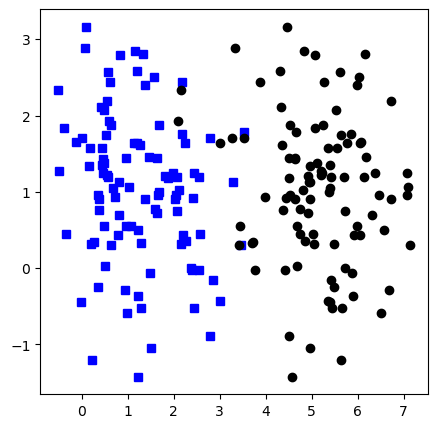

In [75]:
# create data

nPerClust = 100
blur = 1

A = [1, 1]
B = [5, 1]

a = [A[0] + np.random.randn(nPerClust) * blur, A[1] + np.random.randn(nPerClust) * blur]

b = [B[0] + np.random.randn(nPerClust) * blur, B[1] + np.random.randn(nPerClust) * blur]

labels_np = np.vstack((np.zeros((nPerClust, 1)), np.ones((nPerClust, 1))))

data_np = np.hstack((a, b)).T

data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# plot the data
plt.figure(figsize=(5, 5))

plt.plot(data[np.where(labels == 0)[0], 0], data[np.where(labels == 0)[0], 1], "bs")
plt.plot(data[np.where(labels == 1)[0], 0], data[np.where(labels == 0)[0], 1], "ko")

plt.show()

In [76]:
# build the model
ANNclassify = nn.Sequential(
    nn.Linear(2, 1),
    nn.ReLU(),
    nn.Linear(1, 1),
    nn.Sigmoid(),
)

ANNclassify

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1, out_features=1, bias=True)
  (3): Sigmoid()
)

In [77]:
learning_rate = 0.01
lossfun = nn.BCELoss()
optimizer = torch.optim.SGD(ANNclassify.parameters(), lr=learning_rate)

In [78]:
numepochs = 1000
losses = torch.zeros(numepochs)

for i in range(numepochs):
    # forward pass
    y_hat = ANNclassify(data)

    # compute loss
    loss = lossfun(y_hat, labels)
    losses[i] = loss

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

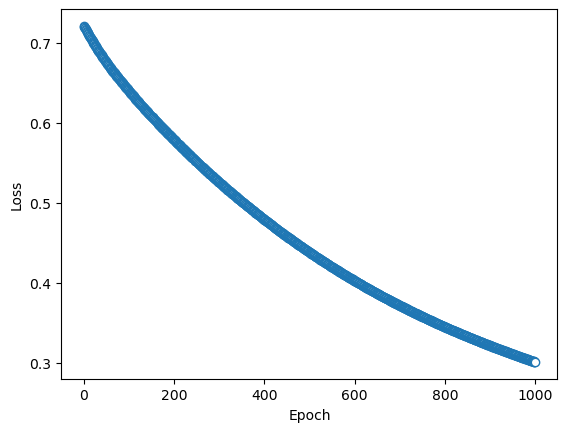

In [79]:
plt.plot(losses.detach(), "o", markerfacecolor="w", linewidth=0.1)
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.show()

In [80]:
# compute the predictions
predictions = ANNclassify(data)
pred_labels = predictions > 0.5

# find errors
missclassified = np.where(pred_labels != labels)[0]

# total accuracy
totalacc = 100 - 100 * len(missclassified) / (2 * nPerClust)

print("Final accuracy: %g%%" % totalacc)

Final accuracy: 90%


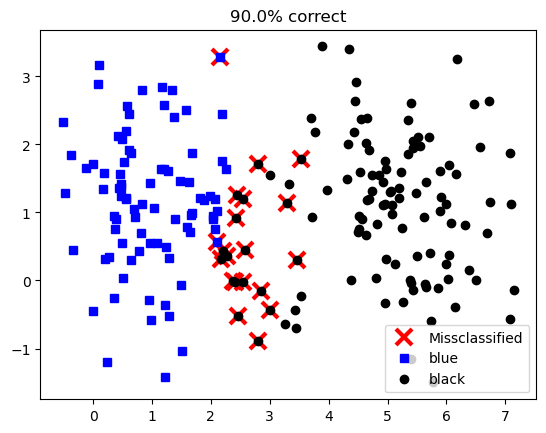

In [84]:
plt.plot(
    data[missclassified, 0],
    data[missclassified, 1],
    "rx",
    markersize=12,
    markeredgewidth=3,
)
plt.plot(data[np.where(~pred_labels)[0], 0], data[np.where(~pred_labels)[0], 1], "bs")
plt.plot(data[np.where(pred_labels)[0], 0], data[np.where(pred_labels)[0], 1], "ko")

plt.legend(["Missclassified", "blue", "black"])
plt.title(f"{totalacc}% correct")
plt.show()